number of pulsars 229744
Best-fit relation: log(SNR) = 1.061 * log(Flux) + 29.312


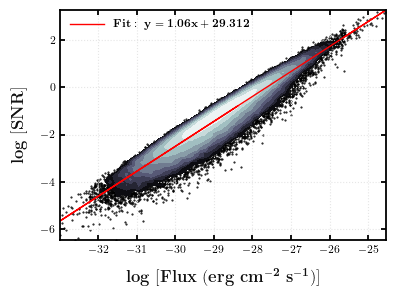

In [30]:
#!pip install astroML
%matplotlib inline
from matplotlib import pyplot as plt
from astroML.plotting import scatter_contour
from psrpoppy import population
import pickle
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import psrpoppy.population as real_population
import pandas as pd
import numpy as np
import multiprocessing
import time
from numba import njit
import sys
path_sys='path to psrpoppy' #replace with path to psrpoppy
sys.path.append(path_sys)
import matplotlib as mpl

#GLOBAL STYLE SETTINGS
mpl.rcParams.update({
    "font.size": 14,                
    "axes.labelweight": "bold",     
    "axes.titlesize": 16,           
    "axes.titleweight": "bold",
    "axes.linewidth": 1.3,         
    "lines.linewidth": 1,         
    "legend.fontsize": 12,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.color": "0.9",
    "grid.linestyle": "--",
    "grid.linewidth": 0.8
})


sys.modules['population'] = real_population
filename='PMSURV_SNR_-10.results'


#df_smr = pd.read_excel("/home/sanjith/PsrPopPy/df_smr.xlsx") #path to the smeared samples 


with open(filename, 'rb') as f:
    pop = pickle.load(f)


fluxes = np.array([psr.s_1400() for psr in pop.population])*1e-26
distances = np.array([psr.dtrue for psr in pop.population])*1e3
snr=np.array([psr.snr for psr in pop.population])
n_samples = len(fluxes)
print("number of pulsars",n_samples)


df = pd.DataFrame({
    'Flux': fluxes,
    'Distance': distances,
    'snr':snr
})

if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=True)


df=df[df['snr']>0]

fig, ax = plt.subplots(figsize=(4,3))
scatter_contour(np.log10(df['Flux']),np.log10(df['snr']), threshold=10, log_counts=True, ax=ax,
                histogram2d_args=dict(bins=80),
                plot_args=dict(marker='.', linestyle='none',markersize=1.0, color='black'),
                contour_args=dict(cmap=plt.cm.bone))


m, c = np.polyfit(np.log10(df['Flux']),np.log10(df['snr']), 1)
print(f"Best-fit relation: log(SNR) = {m:.3f} * log(Flux) + {c:.3f}")
fit_line = m * np.log10(df['Flux']) + c


plt.plot(np.log10(df['Flux']),
    fit_line,
    color='red',
    label=rf"$\mathbf{{Fit:\ y={m:.2f}x+{c:.3f}}}$"
)

plt.xlabel(r"$\mathbf{log\ [Flux\ (erg\ cm^{-2}\ s^{-1})]}$",
           labelpad=10, color="#111111", fontsize=12)

plt.ylabel(r"$\mathbf{log\ [SNR]}$",
           labelpad=10, color="#111111", fontsize=12)


plt.legend(frameon=False,
           loc="upper left",
          framealpha=0.9,
           facecolor="white",
         edgecolor="black")

plt.grid(True)
plt.tight_layout()
#plt.savefig("path/log_snr_log_flux.pdf",dpi=1000, bbox_inches="tight")

plt.show()

 